# Gathering data and preprocessing
## Dependencies and dataset imports

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

In [2]:
pd.set_option('display.max_columns',None)
df = pd.read_parquet("./Dataset/Flight_Delay.parquet")
df.reset_index(drop = True, inplace = True)

## Understanding given data

In [3]:
def describe_columns(givenDataFrame: pd.DataFrame) -> pd.DataFrame:
    summary = []
    for col in givenDataFrame.columns:
        dtype = givenDataFrame[col].dtype
        unique_count = givenDataFrame[col].nunique(dropna=False)
        missing_count = givenDataFrame[col].isna().sum()
        top_values = givenDataFrame[col].value_counts(dropna=False).nlargest(3)

        summary.append({
            "column": col,
            "dtype": dtype,
            "unique_values": unique_count,
        })

    return pd.DataFrame(summary)

summary_df = describe_columns(df)
summary_df

,column,dtype,unique_values
0,Year,int64,6
1,Month,int64,12
2,DayofMonth,int64,31
3,FlightDate,str,1946
4,Marketing_Airline_Network,str,11
5,OriginCityName,str,382
6,DestCityName,str,382
7,CRSDepTime,int64,1426
8,DepTime,float64,1440
9,DepDelay,float64,2100


In [4]:
df.shape

(30132672, 29)

In [5]:
df['FlightDate']

0           2018-01-15
1           2018-01-16
2           2018-01-17
3           2018-01-18
4           2018-01-20
               ...    
30132667    2023-04-26
30132668    2023-04-26
30132669    2023-04-26
30132670    2023-04-26
30132671    2023-04-26
Name: FlightDate, Length: 30132672, dtype: str

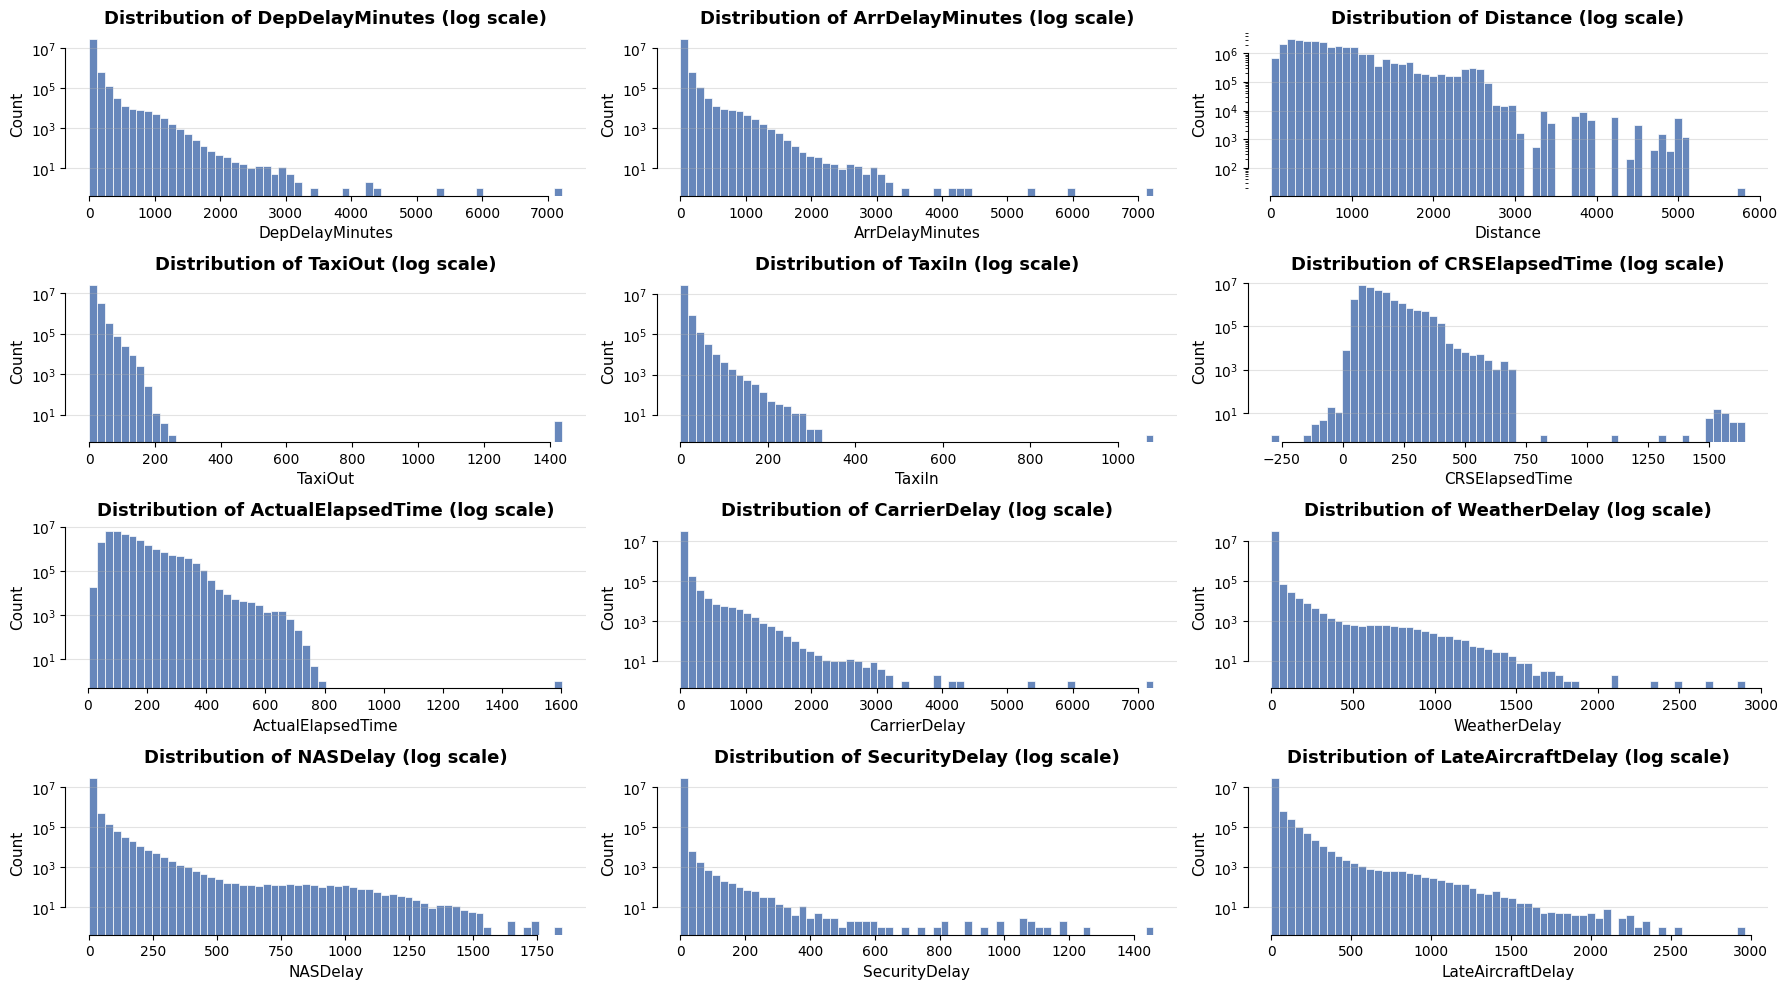

In [6]:
def plot_histogram_grid(
    givenDataFrame: pd.DataFrame,
    columns: list[str],
    ncols: int = 3,
    bins: int = 50,
    log_scale: bool = False,
    figsize: tuple[int, int] = (15, 10)
) -> None:
    ncols = max(1, ncols)
    nrows = (len(columns) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, columns):
        sns.histplot(
            givenDataFrame[col].dropna(),
            bins=bins,
            kde=False,
            color="#4C72B0",
            edgecolor="white",
            linewidth=0.5,
            alpha=0.85,
            ax=ax
        )
        ax.set_title(f"Distribution of {col}", fontsize=13, weight="bold")
        ax.set_xlabel(col, fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        if log_scale:
            ax.set_yscale("log")
            ax.set_title(f"Distribution of {col} (log scale)", fontsize=13, weight="bold")
        ax.grid(axis="y", alpha=0.35)
    
    for empty_ax in axes[len(columns):]:
        empty_ax.axis("off")

    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

plot_histogram_grid(
    df,
    columns=["DepDelayMinutes", "ArrDelayMinutes", "Distance",
             "TaxiOut", "TaxiIn", "CRSElapsedTime" ,"ActualElapsedTime", "CarrierDelay", "WeatherDelay",
             "NASDelay", "SecurityDelay", "LateAircraftDelay"],
    ncols=3,
    bins=60,
    log_scale=True,
    figsize=(18, 10)
)

In [7]:
df['Marketing_Airline_Network'].unique()

<ArrowStringArray>
['UA', 'DL', 'F9', 'NK', 'AA', 'WN', 'AS', 'HA', 'VX', 'B6', 'G4']
Length: 11, dtype: str

Marketing Airline Network is unintelligible. Values shall be changed.

In [8]:
df['OriginCityName']

0              Newark, NJ
1              Newark, NJ
2              Newark, NJ
3              Newark, NJ
4              Newark, NJ
                ...      
30132667      Houston, TX
30132668      Chicago, IL
30132669    Las Vegas, NV
30132670        Miami, FL
30132671        Tampa, FL
Name: OriginCityName, Length: 30132672, dtype: str

OriginCityName contains information about both city and state, for the purposes of this analysis it's better to keep them separated.

In [9]:
print(f"{df.memory_usage(deep=True).sum() / 1e9:.2f} GB")  # in GB

8.14 GB


In [10]:
df.memory_usage(deep=True).sort_values(ascending=False) / 1e6  # MB per column

OriginCityName               636.434308
DestCityName                 636.234861
FlightDate                   542.388096
Marketing_Airline_Network    301.326720
TaxiIn                       241.061376
Distance                     241.061376
ArrDelayMinutes              241.061376
CRSElapsedTime               241.061376
ActualElapsedTime            241.061376
AirTime                      241.061376
WeatherDelay                 241.061376
DistanceGroup                241.061376
CarrierDelay                 241.061376
ArrTime                      241.061376
NASDelay                     241.061376
SecurityDelay                241.061376
ArrDelay                     241.061376
LateAircraftDelay            241.061376
CRSArrTime                   241.061376
Year                         241.061376
WheelsOn                     241.061376
WheelsOff                    241.061376
TaxiOut                      241.061376
DepDelayMinutes              241.061376
DepDelay                     241.061376


### Checking for missing data

In [11]:
def printMissingDataSummary(givenDataFrame: pd.DataFrame) -> None:
    missingCount = givenDataFrame.isna().sum()
    missingPercentage = (missingCount / len(givenDataFrame) * 100).round(2)

    missingSummary = pd.DataFrame({
        "missingCount": missingCount,
        "missingPercentage": missingPercentage
    })

    print("\nMissing data summary:")
    print(missingSummary)

printMissingDataSummary(df)


Missing data summary:
                           missingCount  missingPercentage
Year                                  0                0.0
Month                                 0                0.0
DayofMonth                            0                0.0
FlightDate                            0                0.0
Marketing_Airline_Network             0                0.0
OriginCityName                        0                0.0
DestCityName                          0                0.0
CRSDepTime                            0                0.0
DepTime                               0                0.0
DepDelay                              0                0.0
DepDelayMinutes                       0                0.0
TaxiOut                               0                0.0
WheelsOff                             0                0.0
WheelsOn                              0                0.0
TaxiIn                                0                0.0
CRSArrTime                       

### Checking for duplicates

In [12]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of           Year  Month  DayofMonth  FlightDate Marketing_Airline_Network  \
0         2018      1          15  2018-01-15                        UA   
1         2018      1          16  2018-01-16                        UA   
2         2018      1          17  2018-01-17                        UA   
3         2018      1          18  2018-01-18                        UA   
4         2018      1          20  2018-01-20                        UA   
...        ...    ...         ...         ...                       ...   
30132667  2023      4          26  2023-04-26                        UA   
30132668  2023      4          26  2023-04-26                        UA   
30132669  2023      4          26  2023-04-26                        UA   
30132670  2023      4          26  2023-04-26                        UA   
30132671  2023      4          26  2023-04-26                        UA   

         OriginCityName       DestCityName  CRSDepTime  

### Memory savings

In [13]:
for col in df.select_dtypes(include=['int', 'int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

for col in df.select_dtypes(include=['float']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [14]:
print(f"{df.memory_usage(deep=True).sum() / 1e9:.2f} GB")  # in GB

4.68 GB


## Column operations

### Sanity check

In [15]:
df["speed"] = (df["Distance"] * 1.609344) / (df["ActualElapsedTime"] / 60)
df['speed'].nlargest(100)
df = df[df['speed'] <= 1000]
df.drop('speed', axis=1, inplace=True)


Limiting max speed of Aircrafts to 1000 km / h. Dropping rows with exceeding values.

### Dealing with dates

In [16]:
# Converting Flightdate to datetime format
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

# Creating new column with day of the week
df["DayofWeek"] = df["FlightDate"].dt.day_of_week

# Creating new column for Holidays
cal = calendar()
holidays = cal.holidays(start=df["FlightDate"].min(), end=df["FlightDate"].max())
df["Holidays"] = df["FlightDate"].isin(holidays)

# Dropping redundant Year, Month and DayofMonth columns
df.drop(['Year', 'Month', 'DayofMonth'], axis = 1, inplace = True)

### Arrival / Departure time formatting

In [17]:
# Merging FlightDate with DepTime to create a full datetime column
# DepTime is in HHMM format (e.g., 1928 = 19:28)
def time_to_timedelta(hhmm_time):
    """Convert HHMM format to timedelta"""
    if pd.isna(hhmm_time):
        return pd.NaT
    hhmm_int = int(hhmm_time)
    hours = hhmm_int // 100
    minutes = hhmm_int % 100
    return pd.Timedelta(hours=hours, minutes=minutes)

# Create DepTime datetime column
df['DepTime'] = df['FlightDate'] + df['DepTime'].apply(time_to_timedelta)

# Calculate ArrTime as DepTime + ActualElapsedTime (in minutes)
df['ArrTime'] = df['DepTime'] + pd.to_timedelta(df['ActualElapsedTime'], unit='min')

In [18]:
# Now FlightDate is redundant, as we have full datetime in DepTime and ArrTime
df.drop(['FlightDate'], axis = 1, inplace = True)

# ArrDelay is the same as ArrDelayMinutes
df.drop(['ArrDelay'], axis = 1, inplace = True)

# DepDelay is the same as DepDelayMinutes
df.drop(['DepDelay'], axis = 1, inplace = True)

# WheelsOff contins same information as DepTime
df.drop(['WheelsOff'], axis = 1, inplace = True)

# WheelsOn contins same information as ArrTime
df.drop(['WheelsOn'], axis = 1, inplace = True)

# AirTime is the same as ActualElapsedTime
df.drop(['AirTime'], axis = 1, inplace = True)

# Difference between scheduled flight time and actual flight time is negligible
df.drop(['CRSElapsedTime'], axis = 1, inplace = True)

# Scheduled departures and arrivals can easily be calculated
# CRSDepTime == DepTime - DepDelay
# CRSArrTime == ArrTime - ArrDelay
# therefore they can be dropped without losing information
df.drop(['CRSDepTime', 'CRSArrTime'], axis = 1, inplace = True)

In [19]:
# Check time formatting
df[['DepTime','ArrTime', 'ActualElapsedTime', 'DepDelayMinutes', 'ArrDelayMinutes']].head(10)

,DepTime,ArrTime,ActualElapsedTime,DepDelayMinutes,ArrDelayMinutes
0,2018-01-15 19:28:00,2018-01-15 21:49:00,141.0,43.0,41.0
1,2018-01-16 19:56:00,2018-01-16 22:07:00,131.0,81.0,69.0
2,2018-01-17 18:36:00,2018-01-17 20:54:00,138.0,1.0,0.0
3,2018-01-18 18:44:00,2018-01-18 20:58:00,134.0,0.0,0.0
4,2018-01-20 18:29:00,2018-01-20 20:26:00,117.0,0.0,0.0
5,2018-01-21 18:25:00,2018-01-21 20:44:00,139.0,0.0,0.0
6,2018-01-22 18:47:00,2018-01-22 21:28:00,161.0,2.0,20.0
7,2018-01-23 18:23:00,2018-01-23 21:14:00,171.0,0.0,16.0
8,2018-01-25 18:41:00,2018-01-25 21:03:00,142.0,0.0,0.0
9,2018-01-26 18:38:00,2018-01-26 20:53:00,135.0,0.0,0.0


### Separating Cities from States

In [20]:
# Splitting OriginCityName
df[['OriginCity', 'OriginState']] = df['OriginCityName'].str.split(', ', expand = True)

# Splitting DestCityName
df[['DestCity','DestState']] = df['DestCityName'].str.split(', ', expand = True)

# Dropping the original columns
df.drop(['OriginCityName', 'DestCityName'], axis = 1, inplace = True)

df[['OriginCity', 'OriginState', 'DestCity', 'DestState']]

,OriginCity,OriginState,DestCity,DestState
0,Newark,NJ,Charleston,SC
1,Newark,NJ,Charleston,SC
2,Newark,NJ,Charleston,SC
3,Newark,NJ,Charleston,SC
4,Newark,NJ,Charleston,SC
...,...,...,...,...
30132667,Houston,TX,San Francisco,CA
30132668,Chicago,IL,Philadelphia,PA
30132669,Las Vegas,NV,Chicago,IL
30132670,Miami,FL,Newark,NJ


### Remapping airline names

In [21]:
df.loc[df['Marketing_Airline_Network'] == 'UA', 'CarrierName'] = 'United Airlines'
df.loc[df['Marketing_Airline_Network'] == 'DL', 'CarrierName'] = 'Delta Airlines'
df.loc[df['Marketing_Airline_Network'] == 'F9', 'CarrierName'] = 'Frontier Airlines'
df.loc[df['Marketing_Airline_Network'] == 'NK', 'CarrierName'] = 'Spirit Airlines'
df.loc[df['Marketing_Airline_Network'] == 'AA', 'CarrierName'] = 'American Airlines'
df.loc[df['Marketing_Airline_Network'] == 'WN', 'CarrierName'] = 'Southwest Airlines'
df.loc[df['Marketing_Airline_Network'] == 'AS', 'CarrierName'] = 'Alaska Airlines'
df.loc[df['Marketing_Airline_Network'] == 'HA', 'CarrierName'] = 'Hawaiian Airlines'
df.loc[df['Marketing_Airline_Network'] == 'VX', 'CarrierName'] = 'Virgin America'
df.loc[df['Marketing_Airline_Network'] == 'B6', 'CarrierName'] = 'JetBlue Airways'
df.loc[df['Marketing_Airline_Network'] == 'G4', 'CarrierName'] = 'Allegiant Air'

df['CarrierName'].unique()
df.drop(['Marketing_Airline_Network'], axis = 1, inplace = True)

### Misc vestiges

In [22]:
# Distance group is unncessary, since we have the actual Distance column
df.drop(['DistanceGroup'], axis = 1, inplace = True)

### Renaming columns for consistency

In [23]:
df.rename(columns={"DepTime": "departure_time",
                   "DepDelayMinutes": "departure_delay",
                   "TaxiIn": "taxi_in",
                   "TaxiOut": "taxi_out",
                   "ArrTime": "arrival_time",
                   "ArrDelayMinutes": "arrival_delay",
                   "ActualElapsedTime": "air_time",
                   "Distance": "distance",
                   "CarrierDelay": "carrier_delay",
                   "WeatherDelay": "weather_delay",
                   "NASDelay": "nas_delay",
                   "SecurityDelay": "security_delay",
                   "LateAircraftDelay": "late_aircraft_delay",
                   "DayofWeek": "day_of_week",
                   "Holidays": "is_holiday",
                   "OriginCity": "origin_city",
                   "OriginState": "origin_state",
                   "DestCity": "dest_city",
                   "DestState": "dest_state",
                   "CarrierName": "carrier_name"
                   }, inplace=True)

### Correlation Matrix 

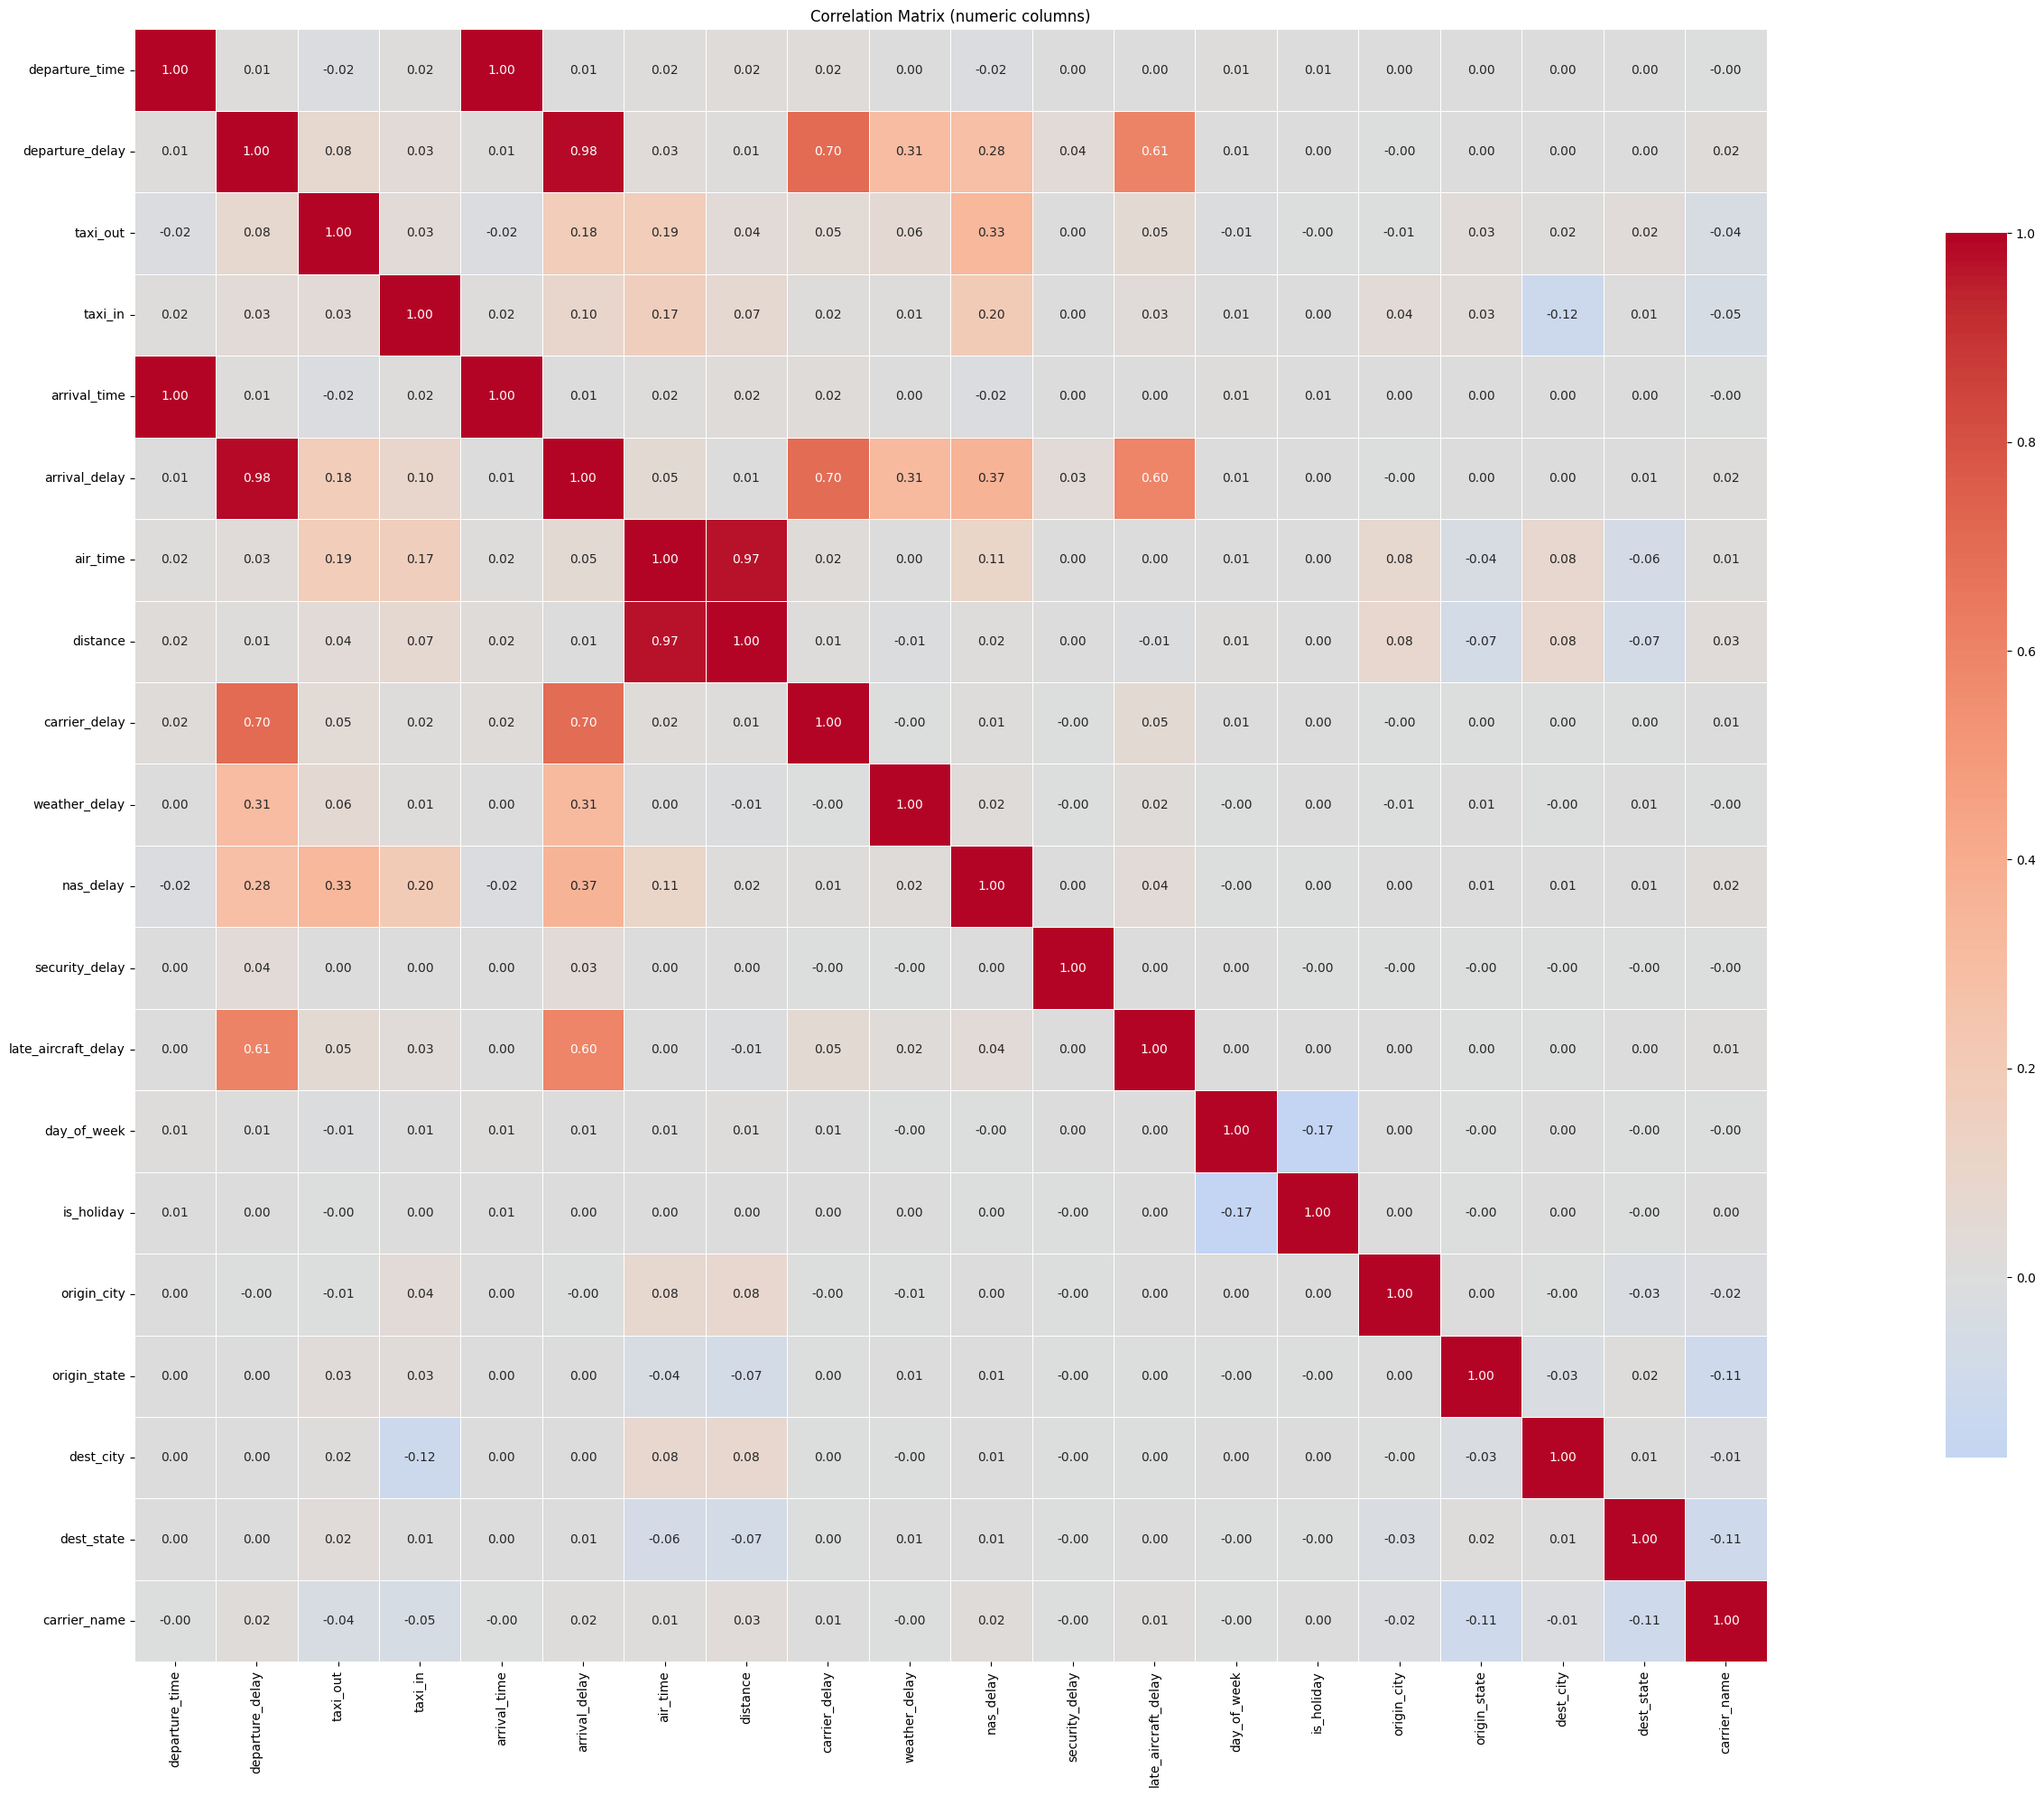


Pairs with |correlation| > 0.6:
      feature_a           feature_b  corr
 departure_time        arrival_time 1.000
departure_delay       arrival_delay 0.982
       air_time            distance 0.969
departure_delay       carrier_delay 0.702
  arrival_delay       carrier_delay 0.695
departure_delay late_aircraft_delay 0.608


In [24]:
def encodeNonNumericForCorr(givenDataFrame: pd.DataFrame) -> pd.DataFrame:
    currentDataFrame = givenDataFrame.copy()
    for col in currentDataFrame.select_dtypes(include=["object", "string", "datetime"]).columns:
        currentDataFrame[col] = currentDataFrame[col].astype("category").cat.codes
    return currentDataFrame

def plotCorrHeatmap(corr: pd.DataFrame) -> None:
    plt.figure(figsize=(40, 20))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.75}
    )
    plt.title("Correlation Matrix (numeric columns)")
    plt.tight_layout()
    plt.show()


def extractStrongCorrPairs(corr: pd.DataFrame, threshold: float = 0.6) -> pd.DataFrame:
    upperMask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    corrPairs = corr.where(upperMask).stack().reset_index()
    corrPairs.columns = ["feature_a", "feature_b", "corr"]

    strongPairs = corrPairs.loc[corrPairs["corr"].abs() > threshold].copy()
    strongPairs = strongPairs.sort_values("corr", key=lambda s: s.abs(), ascending=False)
    return strongPairs


def printStrongCorrPairs(strongPairs: pd.DataFrame, threshold: float = 0.6) -> None:
    print(f"\nPairs with |correlation| > {threshold}:")
    if strongPairs.empty:
        print("No pairs satisfy the condition.")
        return

    print(strongPairs.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


def printComputationMatrix(givenDataFrame: pd.DataFrame) -> None:
    encodedDf = encodeNonNumericForCorr(givenDataFrame)
    corr = encodedDf.corr(numeric_only=True)

    plotCorrHeatmap(corr)
    strongPairs = extractStrongCorrPairs(corr, threshold=0.6)
    printStrongCorrPairs(strongPairs, threshold=0.6)


printComputationMatrix(df)

Extremely high correlation between DepTime and ArrTime is due to the usage of datetime format. It's important to retain both of these columns for this analysis.  

In [25]:
# TO-DO:
# Rozkłady wartości
# GitHub

### Target Variable

Since our goal is to create an imbalanced regresssion model for delay its best to understand the differences between the types of delay present in this dataset. Delays explained:

`departure_delay` → Total departure delay (in minutes)

`arrival_delay` → Total arrival delay (in minutes)

`carrier_delay` → airline-related issues (crew, maintenance, etc.)

`weather_delay` → bad weather

`nas_delay` → air traffic control / airport system issues

`security_delay` → security-related delays

`late_aircraft_delay` → previous flight was late (domino effect)

In this analysis the target variable to base our regression model on is the `arrival_delay` column.

### Relevance function

In [26]:
phi = df["arrival_delay"].rank(pct=True)

We chose the rank based, imbalance-aware relevance function, formally:
\begin{align*}
\Phi{x_i} & = \frac{rank\left(x_i\right)}{N}\\
\end{align*}
This way, the model will focus on relative importance instead of absolute units and retain the significance of the tail-end.

### Column state after initial processing

In [27]:
describe_columns(df)

,column,dtype,unique_values
0,departure_time,datetime64[us],2322286
1,departure_delay,float32,1975
2,taxi_out,float32,207
3,taxi_in,float32,268
4,arrival_time,datetime64[us],2573401
5,arrival_delay,float32,1974
6,air_time,float32,738
7,distance,float32,1752
8,carrier_delay,float32,1884
9,weather_delay,float32,1379


# Imbalanced Preprocessing

# Modelling and Evaluation